In [5]:
import os
from dotenv import load_dotenv
import mysql.connector
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 1. 폰트 파일 경로 지정
font_path = '/home/hong/project/ai-camp-note/week1/content/NanumBarunGothic.ttf'
# 2. 폰트 이름 가져오기
    # 폰트 등록
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
# 3. 모든 폰트 설정 업데이트
plt.rc('font', family=font_name)
# 마이너스 기호 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

# 환경 변수 로드
load_dotenv() # .env 파일의 내용을 환경 변수로 불러옴

config = {
    'host': os.getenv('DB_HOST'),
    'port': 3306,
    'user': os.getenv('DB_USER'),
    'password': os.getenv('DB_PASSWORD'), 
    'database': 'practice_db',
    'connection_timeout': 10
}
# 지역명(label)과 캠핑장 개수(ratio)를 저장할 리스트 초기화
with mysql.connector.connect(**config) as conn:
    with conn.cursor() as cursor:
        cursor.execute('''
        SELECT 
            substr(지번주소, 1, instr(지번주소, ' ')) as location, 
            count(camping_info_id) 
        FROM camping_info 
        group by location
        ''')
        data = cursor.fetchall()
# SQL 조회 결과를 반복문을 통해 리스트에 저장
label = []
ratio = []
for i, j in data:
    label.append(i)
    ratio.append(j)

<function matplotlib.pyplot.show(close=None, block=None)>

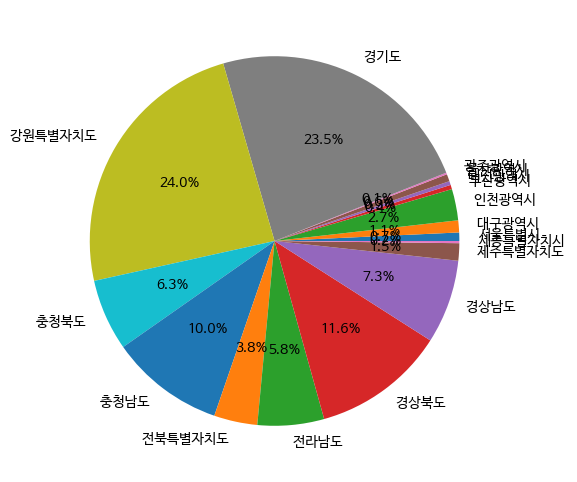

In [6]:
plt.figure(figsize=(10, 6))
plt.pie(ratio, labels=label, autopct='%.1f%%')
plt.show

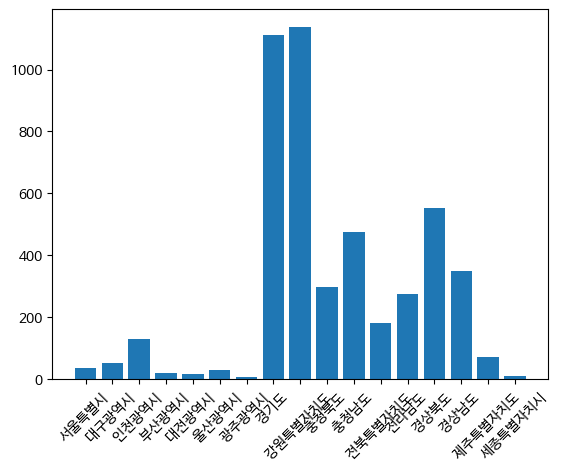

In [7]:
# 막대그래프 그리기
x = np.arange(len(data))   # X축 좌표 (0부터 시작하는 정수 배열)
plt.bar(x, ratio)
plt.xticks(x, label)
plt.xticks(rotation=45)
plt.show()

In [8]:
import pandas as pd

with mysql.connector.connect(**config) as conn:
    vip_df = pd.read_sql_query('''
        SELECT 
            oc.customerNumber,
            oc.orderCount,
            pt.totalSpent
        FROM (
            SELECT customerNumber, COUNT(orderNumber) as orderCount 
            FROM orders 
            GROUP BY customerNumber
        ) oc
        JOIN (
            SELECT customerNumber, SUM(amount) as totalSpent 
            FROM payments 
            GROUP BY customerNumber
        ) pt ON oc.customerNumber = pt.customerNumber
        ORDER BY totalSpent DESC
        limit 10
    ''', conn)

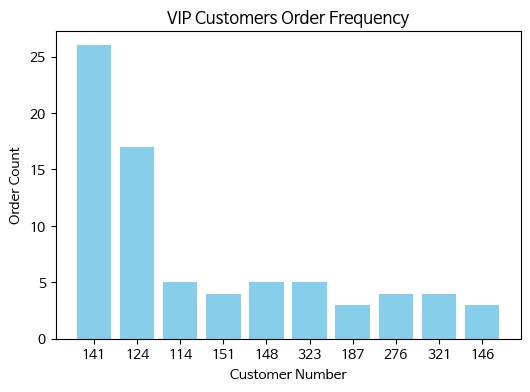

In [9]:
# 구매 빈도 시각화
plt.figure(figsize=(6,4))
plt.bar(vip_df['customerNumber'].astype(str), vip_df['orderCount'], color = 'skyblue')
plt.xlabel('Customer Number')
plt.ylabel('Order Count')
plt.title('VIP Customers Order Frequency')
plt.show()

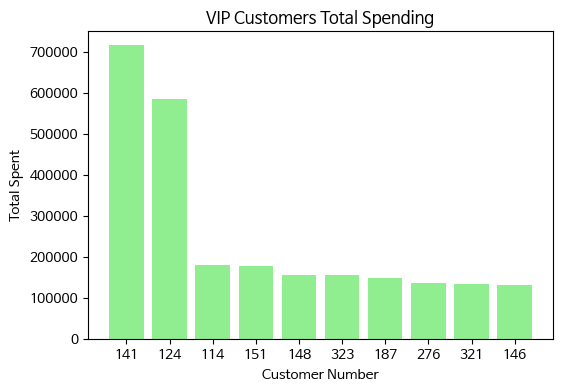

In [10]:
# 구매 금액 시각화
plt.figure(figsize=(6,4))
plt.bar(vip_df['customerNumber'].astype(str), vip_df['totalSpent'], color = 'lightgreen')
plt.xlabel('Customer Number')
plt.ylabel('Total Spent')
plt.title('VIP Customers Total Spending')
plt.show()

In [56]:
with mysql.connector.connect(**config) as conn:
    purchase_change_df = pd.read_sql_query('''
        SELECT 
            p.customerNumber,
            SUM(CASE WHEN YEAR(paymentDate) = 2004 THEN amount ELSE 0 END) AS previous_period_total,
            SUM(CASE WHEN YEAR(paymentDate) = 2005 THEN amount ELSE 0 END) AS recent_period_total
        FROM payments p
        GROUP BY p.customerNumber
    ''', conn)

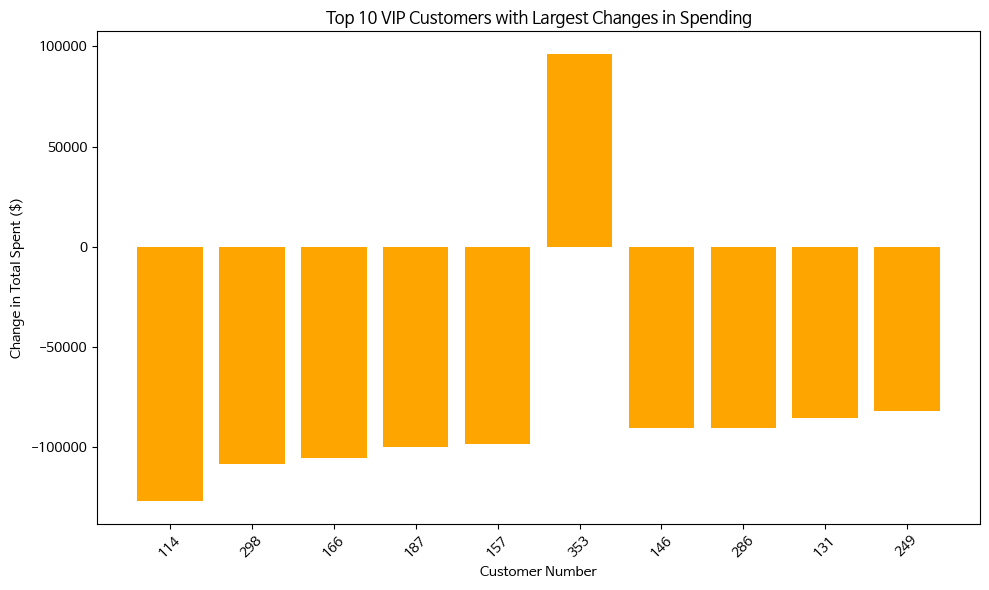

In [59]:
# 구매 금액 변화 계산
purchase_change_df['change_in_spending'] = purchase_change_df['recent_period_total'] - purchase_change_df['previous_period_total']

# 변화량의 절대값에 따라 상위 10개 고객 선택
top_10_customers_change = purchase_change_df.assign(
    abs_change_in_spending=purchase_change_df['change_in_spending'].abs()
).nlargest(10, 'abs_change_in_spending')

# 상위 10개 고객의 원래 변화량 시각화
plt.figure(figsize=(10, 6))

plt.bar(
    top_10_customers_change['customerNumber'].astype(str),
    purchase_change_df.loc[top_10_customers_change.index, 'change_in_spending'],
    color='orange'
)

plt.xlabel('Customer Number')
plt.ylabel('Change in Total Spent ($)')
plt.title('Top 10 VIP Customers with Largest Changes in Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

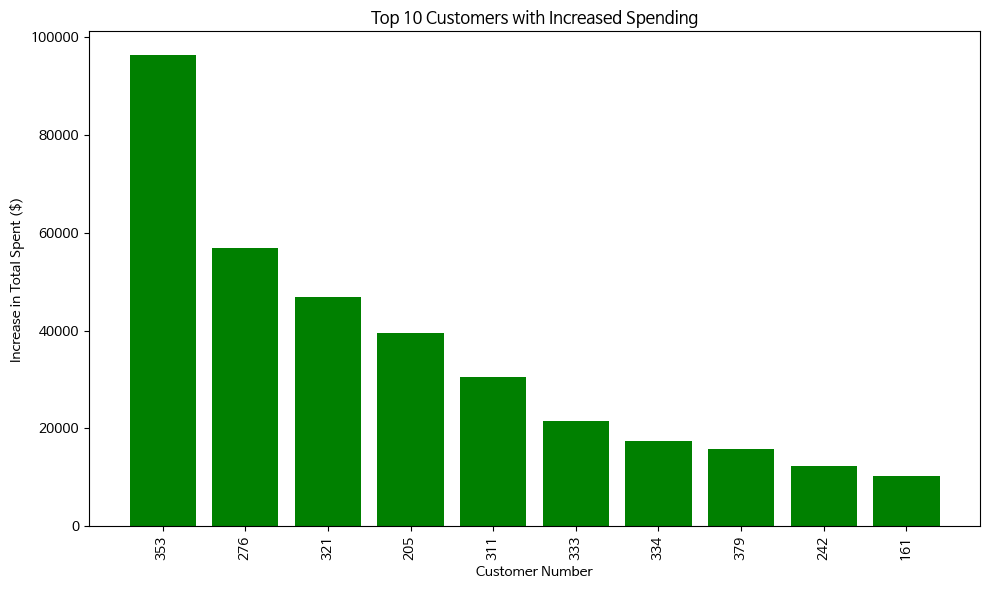

In [60]:
# 구매 금액 변화량이 증가한 상위 10명의 고객
increased_spending_top10 = purchase_change_df[purchase_change_df['change_in_spending'] > 0].nlargest(10, 'change_in_spending')

# 구매 금액 변화량이 감소한 상위 10명의 고객
decreased_spending_top10 = purchase_change_df[purchase_change_df['change_in_spending'] < 0] \
                                .nsmallest(10, 'change_in_spending') \
                                .sort_values(by='change_in_spending', ascending=True)

# 증가한 고객의 변화량 시각화
plt.figure(figsize=(10, 6))
plt.bar(increased_spending_top10['customerNumber'].astype(str), increased_spending_top10['change_in_spending'], color='green')
plt.xlabel('Customer Number')
plt.ylabel('Increase in Total Spent ($)')
plt.title('Top 10 Customers with Increased Spending')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

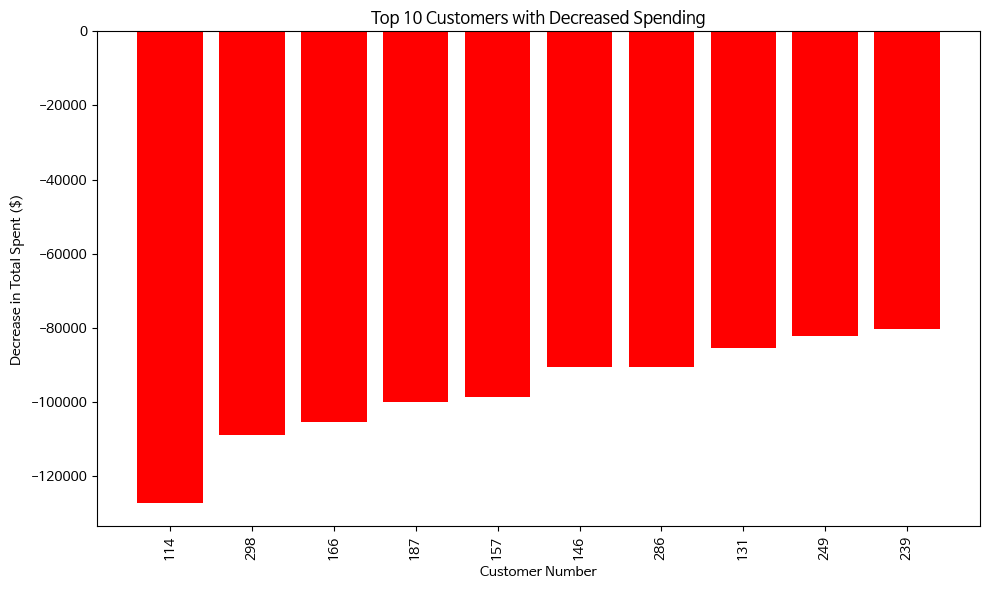

In [61]:
# 감소한 고객의 변화량 시각화
plt.figure(figsize=(10, 6))
plt.bar(decreased_spending_top10['customerNumber'].astype(str), decreased_spending_top10['change_in_spending'], color='red')
plt.xlabel('Customer Number')
plt.ylabel('Decrease in Total Spent ($)')
plt.title('Top 10 Customers with Decreased Spending')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [15]:
# 고객 충성도 분석 쿼리 실행
# 각 고객의 총 주문수(total_order)와 가장 최근의 주문 날짜(last_order_date)를 조회하는 쿼리
with mysql.connector.connect(**config) as conn:
    loyalty_df = pd.read_sql_query('''
        SELECT 
            customerNumber,
            count(orderNumber) as total_orders,
            max(orderDate) as last_order_date
        FROM orders
        GROUP BY customerNumber
    ''', conn)

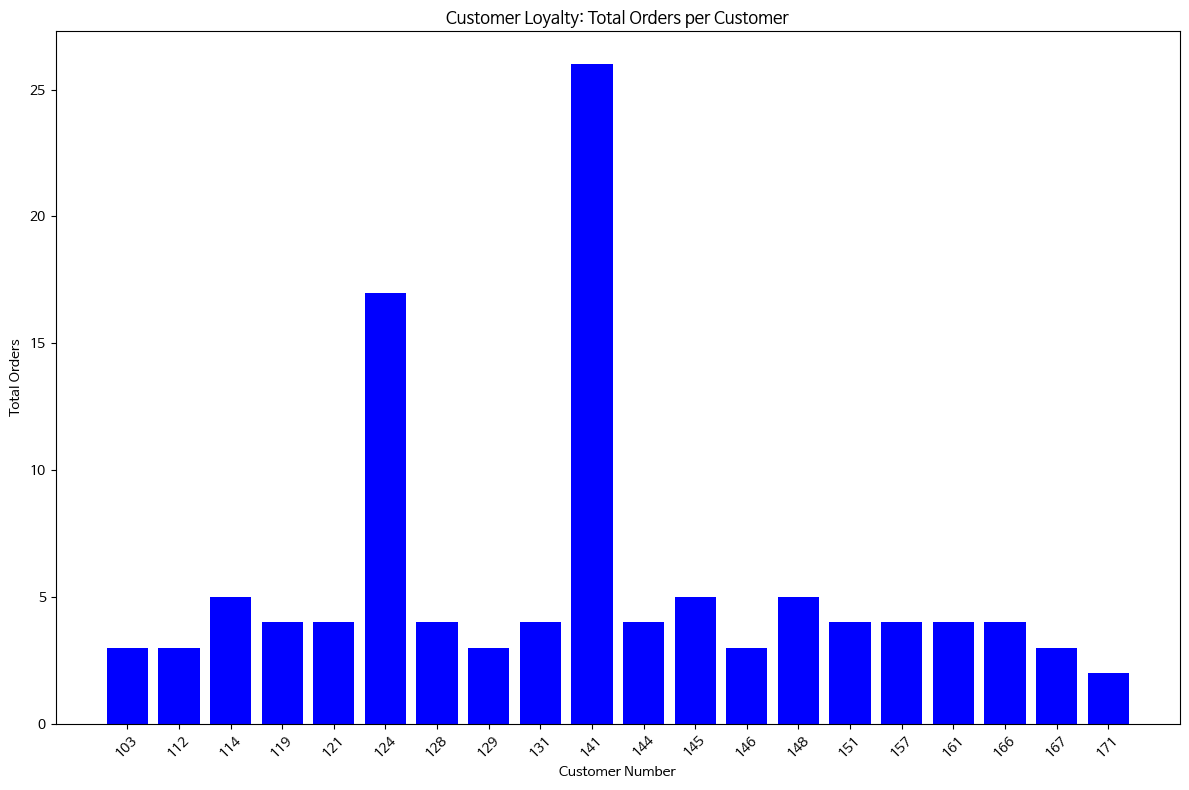

In [16]:
top_20_customers = loyalty_df.head(20)

# 고객별 총 주문 수 시각화 (고객 번호 사용)
plt.figure(figsize=(12, 8))
plt.bar(top_20_customers['customerNumber'].astype(str), top_20_customers['total_orders'], color='blue')
plt.xlabel('Customer Number')
plt.ylabel('Total Orders')
plt.title('Customer Loyalty: Total Orders per Customer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

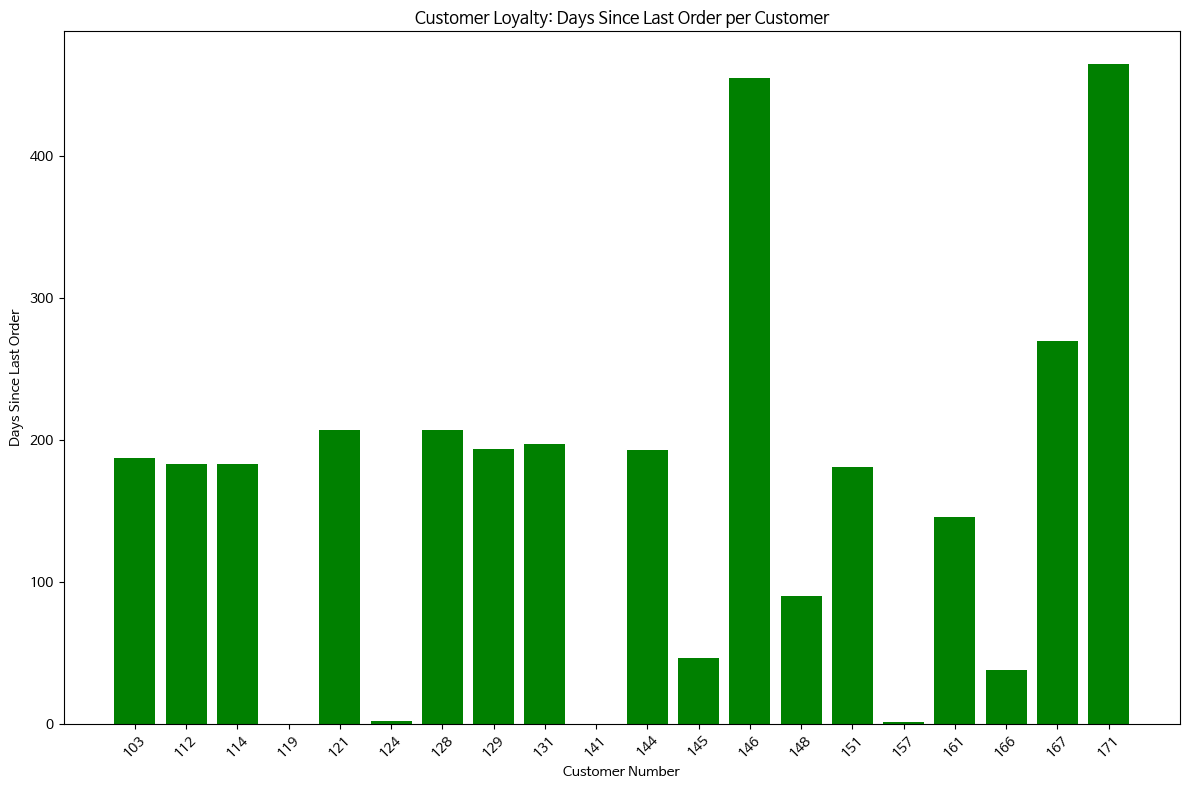

In [17]:
# 데이터셋 내의 최신 구매일을 기준으로 경과된 일수 계산
latest_order_date = loyalty_df['last_order_date'].max()
top_20_customers['days_since_last_order'] = (pd.to_datetime(latest_order_date) - pd.to_datetime(top_20_customers['last_order_date'])).dt.days

# 고객별 마지막 구매로부터 경과된 일수 시각화 (고객 번호 사용)
plt.figure(figsize=(12, 8))
plt.bar(top_20_customers['customerNumber'].astype(str), top_20_customers['days_since_last_order'], color='green')
plt.xlabel('Customer Number')
plt.ylabel('Days Since Last Order')
plt.title('Customer Loyalty: Days Since Last Order per Customer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# 가장 잘 팔리는 제품 분석 쿼리 실행
# 각 제품의 총 판매량(total_quantity)를 계산하고, 가장 많이 팔린 제품을 상위 5개 출력
# 가장 안 팔리는 제품 분석 쿼리 실행

# 가장 많이 팔린 제품 분석 쿼리 실행
# 각 제품의 총 매출(total_sales)을 계산하고, 가장 높은 매출을 기록한 상위 5개 제품을 찾는 쿼리
# 가장 적게 팔린 제품 분석 쿼리 실행
with mysql.connector.connect(**config) as conn:
    top_products_df = pd.read_sql_query('''
        SELECT 
            p.productCode,
            p.productName,
            count(od.orderNumber) as total_quantity
        FROM products p
            join orderdetails od on p.productCode = od.productCode
        GROUP BY p.productCode, p.productName
        order by total_quantity desc
        limit 5
    ''', conn)
    bottom_products_df = pd.read_sql_query('''
        SELECT 
            p.productCode,
            p.productName,
            count(od.orderNumber) as total_quantity
        FROM products p
            join orderdetails od on p.productCode = od.productCode
        GROUP BY p.productCode, p.productName
        order by total_quantity asc
        limit 5
    ''', conn)
    top_price_df = pd.read_sql_query('''
        SELECT 
            p.productCode,
            p.productName,
            sum(od.priceEach) as total_sales
        FROM products p
            join orderdetails od on p.productCode = od.productCode
        GROUP BY p.productCode, p.productName
        order by total_sales desc
        limit 5
    ''', conn)
    bottom_price_df = pd.read_sql_query('''
        SELECT 
            p.productCode,
            p.productName,
            count(od.priceEach) as total_sales
        FROM products p
            join orderdetails od on p.productCode = od.productCode
        GROUP BY p.productCode, p.productName
        order by total_sales asc
        limit 5
    ''', conn)

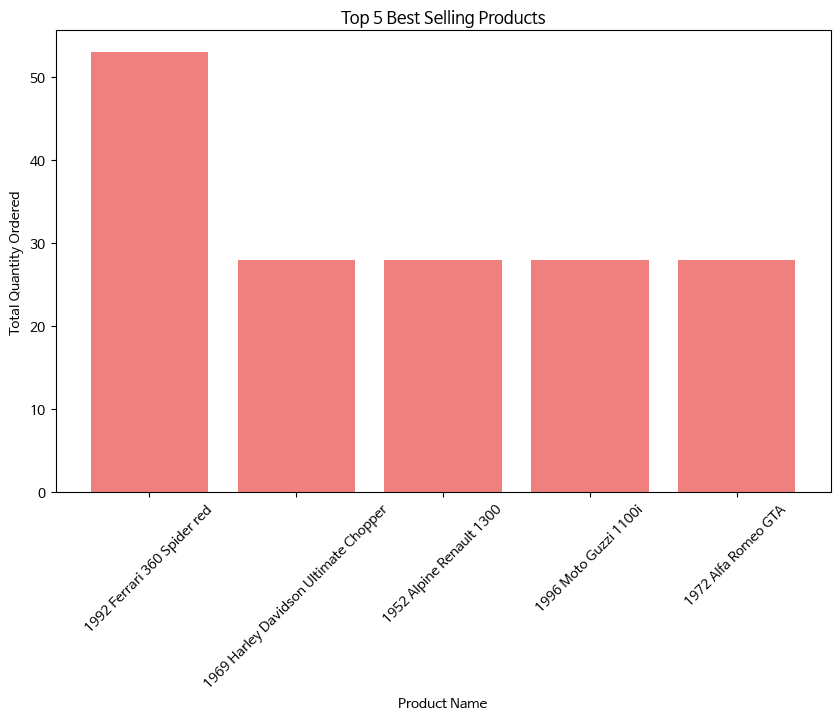

In [19]:
# 가장 잘 팔리는 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(top_products_df['productName'], top_products_df['total_quantity'], color='lightcoral')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Ordered')
plt.title('Top 5 Best Selling Products')
plt.xticks(rotation=45)
plt.show()

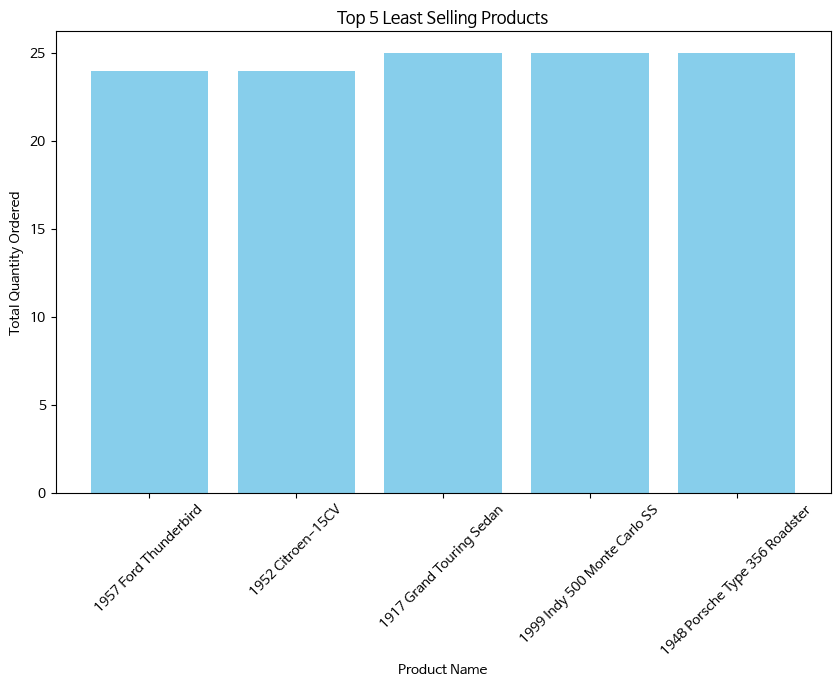

In [20]:
# 가장 안 팔리는 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(bottom_products_df['productName'], bottom_products_df['total_quantity'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Quantity Ordered')
plt.title('Top 5 Least Selling Products')
plt.xticks(rotation=45)
plt.show()

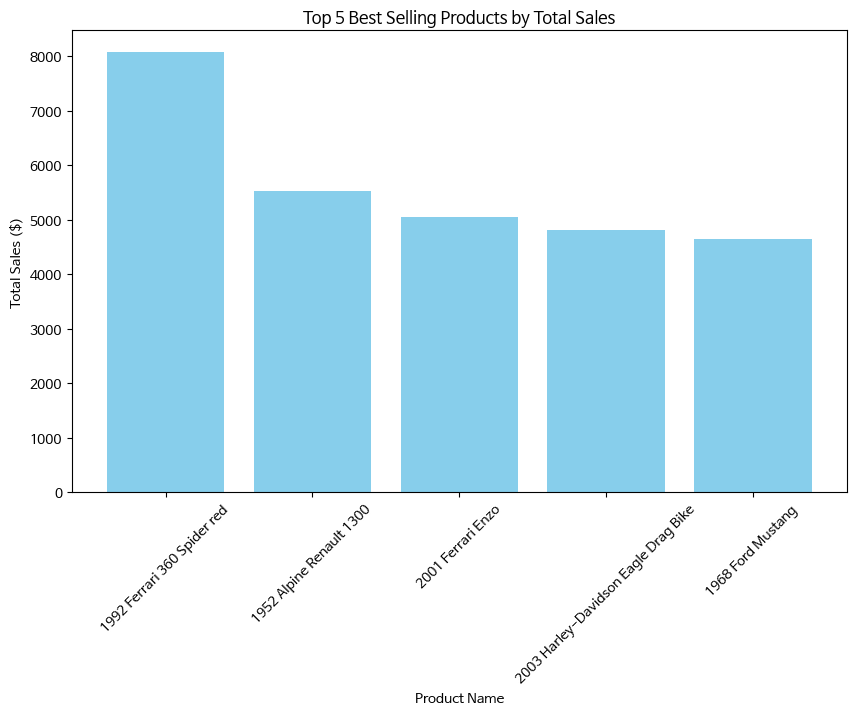

In [21]:
# 가장 많이 팔린 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(top_price_df['productName'], top_price_df['total_sales'], color='skyblue')
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.title('Top 5 Best Selling Products by Total Sales')
plt.xticks(rotation=45)
plt.show()

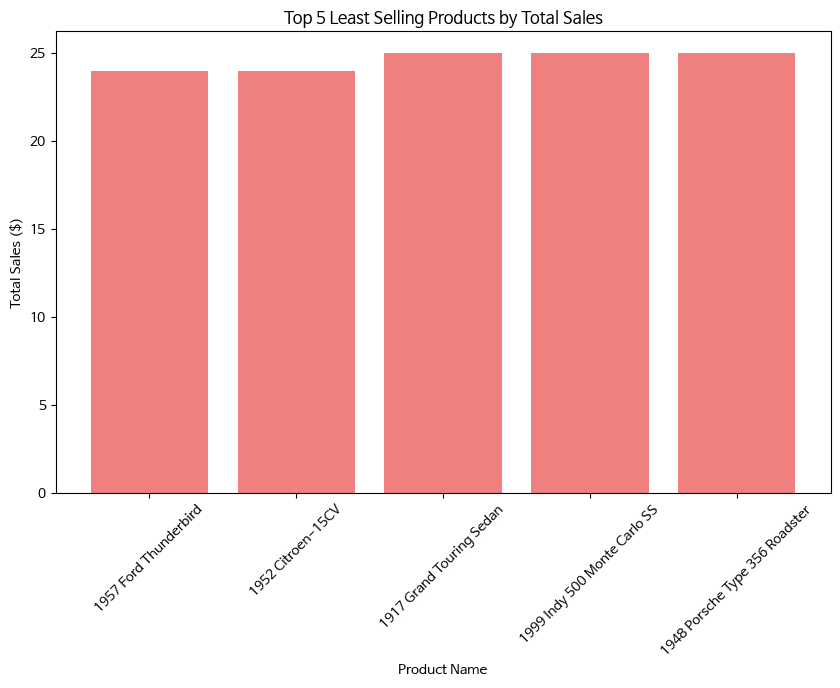

In [22]:
# 가장 적게 팔린 제품 시각화
plt.figure(figsize=(10, 6))
plt.bar(bottom_price_df['productName'], bottom_price_df['total_sales'], color='lightcoral')
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.title('Top 5 Least Selling Products by Total Sales')
plt.xticks(rotation=45)
plt.show()

In [23]:
# 제품 카테고리별 매출 분석 쿼리 실행
# 각 제품 라인(productLine)에 대한 총 매출(total_sales)과 평균 매출(average_sales)을 계산하는 쿼리
with mysql.connector.connect(**config) as conn:
    category_sales_df = pd.read_sql_query('''
        select
            productLine,
            sum(od.priceEach) as total_sales,
            avg(od.priceEach)average_sales
        from products p
            join orderdetails od on p.productCode = od.productCode
        group by p.productLine
    ''', conn)

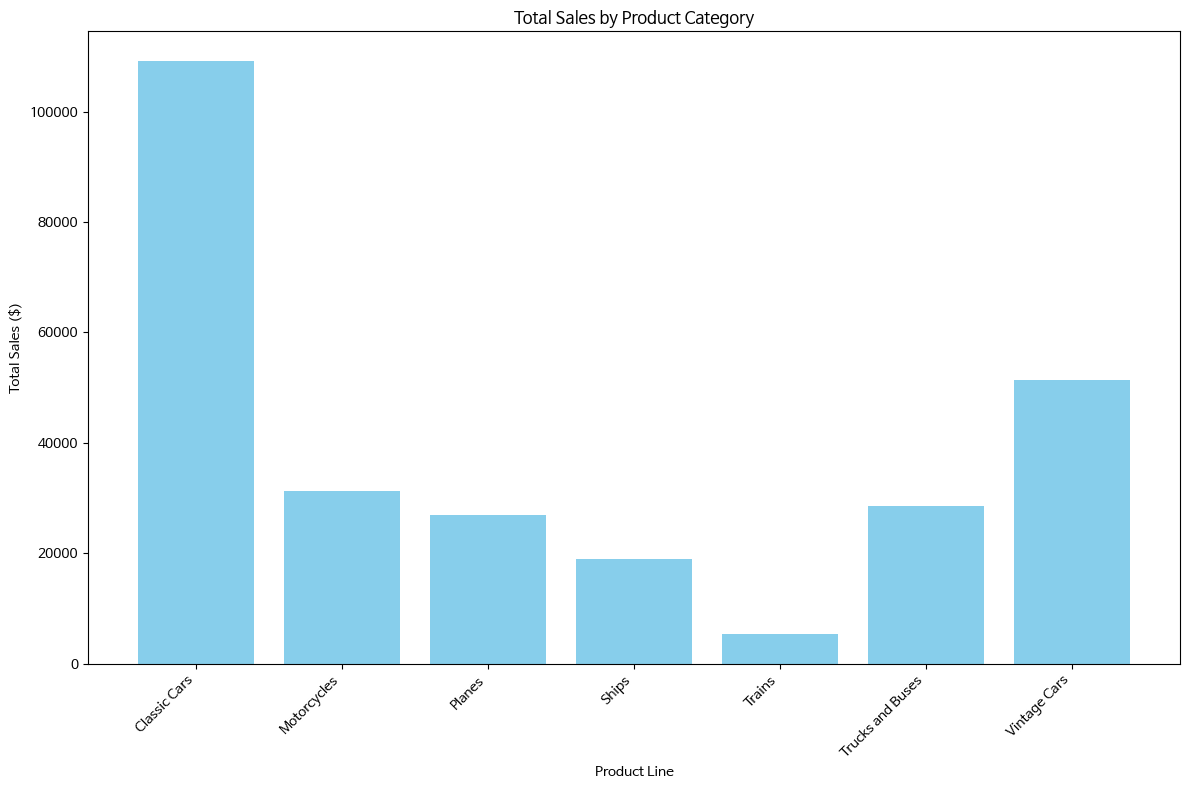

In [24]:
# 총 매출 시각화
plt.figure(figsize=(12, 8))
plt.bar(category_sales_df['productLine'], category_sales_df['total_sales'], color='skyblue')
plt.xlabel('Product Line')
plt.ylabel('Total Sales ($)')
plt.title('Total Sales by Product Category')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

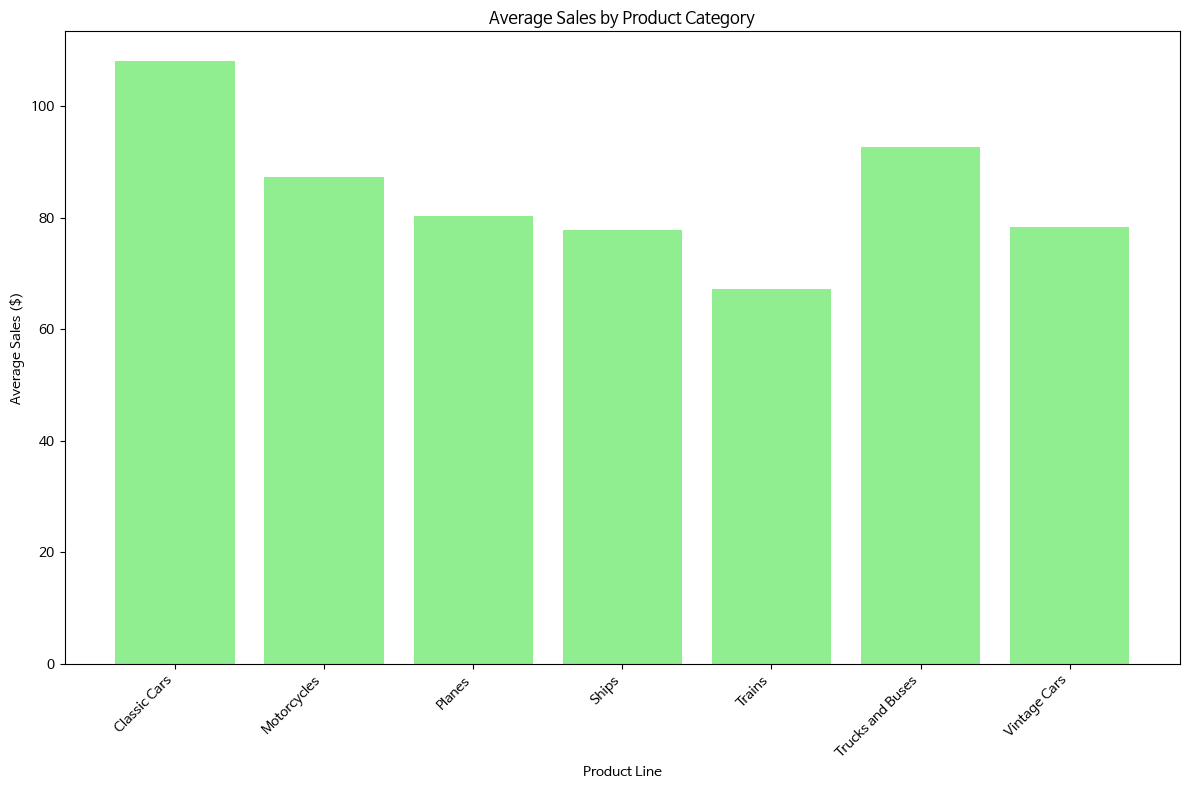

In [25]:
# 평균 매출 시각화
plt.figure(figsize=(12, 8))
plt.bar(category_sales_df['productLine'], category_sales_df['average_sales'], color='lightgreen')
plt.xlabel('Product Line')
plt.ylabel('Average Sales ($)')
plt.title('Average Sales by Product Category')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [31]:
import seaborn as sns

# 각 고객(customerNumber)의 주문 횟수(orderCount)와 
# 평균 주문 금액(avgOrderValue)를 계산하여, 
# 가장 많은 주문을 한 고객부터 정렬하는 분석용 쿼리
# 즉, 어떤 고객이 가장 자주 주문했으며, 
# 평균적으로 얼마나 많은 금액을 주문했는지 분석하는 것이 목적
with mysql.connector.connect(**config) as conn:
    customer_df = pd.read_sql_query('''
        WITH OrderTotals AS (
            -- 1. 각 주문(orderNumber)별 총 주문 금액 계산
            SELECT 
                o.customerNumber,
                o.orderNumber,
                SUM(od.quantityOrdered * od.priceEach) AS totalOrderValue
            FROM orders o
            JOIN orderdetails od ON o.orderNumber = od.orderNumber
            GROUP BY o.customerNumber, o.orderNumber
        )
        -- 2. 고객별 주문 횟수 및 평균 주문 금액 집계
        SELECT 
            customerNumber,
            COUNT(orderNumber) AS orderCount,       -- 주문 횟수
            AVG(totalOrderValue) AS avgOrderValue   -- 평균 주문 금액
        FROM OrderTotals
        GROUP BY customerNumber
        ORDER BY orderCount DESC, avgOrderValue DESC; -- 주문 횟수가 많은 순으로 정렬
    ''', conn)

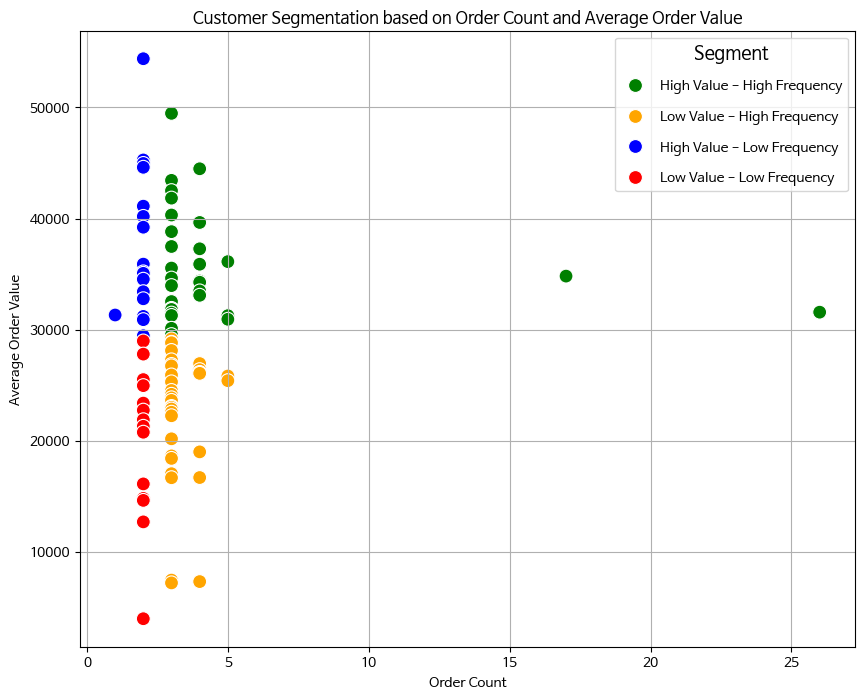

' \n그룹 별 마케팅\n\nHigh Value - High Frequency (HVHF)\n특징: 이 그룹의 고객들은 높은 주문 가치와 빈번한 구매 행동을 보임.\n추천 마케팅 전략: 로열티 프로그램: 이들은 이미 브랜드에 충성도가 높은 고객군. 로열티 포인트, VIP 서비스 등을 제공하여 이들의 충성도를 더욱 강화.\n업셀링 및 크로스셀링: 관련 제품이나 더 고가의 제품을 제안하여 구매를 유도.\n개인화된 커뮤니케이션: 이메일 마케팅, SMS 등을 통해 개인화된 제안과 정보를 제공.\n\nHigh Value - Low Frequency (HVLF)\n특징: 높은 주문 가치를 보이지만 구매 빈도는 낮은 고객군.\n추천 마케팅 전략: 재구매 유도: 할인 쿠폰, 한정 판매 제품 정보 등을 제공하여 재구매를 유도.\n이벤트 초대: 특별 이벤트나 신제품 출시 행사에 이들을 초대하여 관심을 유도.\n피드백 요청: 제품이나 서비스에 대한 피드백을 요청하여 관계를 강화하고, 개선점을 찾음.\n\nLow Value - High Frequency (LVHF)\n특징: 자주 구매하지만 주문 가치는 낮은 고객군.\n추천 마케팅 전략: 가치 제안 강화: 더 높은 가치의 제품을 합리적인 가격에 제안하여 평균 주문 가치를 높임.\n번들 판매: 관련 제품을 함께 묶어서 판매하여 더 높은 가치의 구매를 유도.\n교육 및 정보 제공: 제품 사용법, 관련 정보를 제공하여 제품에 대한 인식을 높이고, 더 높은 가치 제품으로의 이동을 유도.\n\nLow Value - Low Frequency (LVLF)\n특징: 낮은 주문 가치와 드문 구매 행동을 보이는 고객군.\n추천 마케팅 전략: 인식 향상 캠페인: 브랜드 인식을 높이기 위한 마케팅 캠페인을 진행.\n입문 제품 제안: 저렴한 가격의 입문 제품을 제안하여 제품에 대한 관심을 유도.\n소셜 미디어 마케팅: 소셜 미디어를 통해 브랜드와 제품에 대한 인식을 증가. \n'

In [32]:
# 세분화 기준 정의 (임의로 설정)
orderCount_median = customer_df['orderCount'].median()
avgOrderValue_median = customer_df['avgOrderValue'].median()

# 세분화 레이블링
customer_df['Segment'] = np.where((customer_df['orderCount'] >= orderCount_median) & (customer_df['avgOrderValue'] >= avgOrderValue_median), 'High Value - High Frequency',
                                  np.where((customer_df['orderCount'] < orderCount_median) & (customer_df['avgOrderValue'] >= avgOrderValue_median), 'High Value - Low Frequency',
                                           np.where((customer_df['orderCount'] >= orderCount_median) & (customer_df['avgOrderValue'] < avgOrderValue_median), 'Low Value - High Frequency', 'Low Value - Low Frequency')))

# 세그먼트별 색상 매핑
color_map = {
    'High Value - High Frequency': 'green',
    'High Value - Low Frequency': 'blue',
    'Low Value - High Frequency': 'orange',
    'Low Value - Low Frequency': 'red'
}

# 산점도 시각화
plt.figure(figsize=(10, 8))
sns.scatterplot(data=customer_df, x='orderCount', y='avgOrderValue', hue='Segment', palette=color_map, s=100)
plt.title('Customer Segmentation based on Order Count and Average Order Value')
plt.xlabel('Order Count')
plt.ylabel('Average Order Value')
plt.legend(title='Segment', title_fontsize='13', labelspacing=1.2)
plt.grid(True)
plt.show()

""" 
그룹 별 마케팅

High Value - High Frequency (HVHF)
특징: 이 그룹의 고객들은 높은 주문 가치와 빈번한 구매 행동을 보임.
추천 마케팅 전략: 로열티 프로그램: 이들은 이미 브랜드에 충성도가 높은 고객군. 로열티 포인트, VIP 서비스 등을 제공하여 이들의 충성도를 더욱 강화.
업셀링 및 크로스셀링: 관련 제품이나 더 고가의 제품을 제안하여 구매를 유도.
개인화된 커뮤니케이션: 이메일 마케팅, SMS 등을 통해 개인화된 제안과 정보를 제공.

High Value - Low Frequency (HVLF)
특징: 높은 주문 가치를 보이지만 구매 빈도는 낮은 고객군.
추천 마케팅 전략: 재구매 유도: 할인 쿠폰, 한정 판매 제품 정보 등을 제공하여 재구매를 유도.
이벤트 초대: 특별 이벤트나 신제품 출시 행사에 이들을 초대하여 관심을 유도.
피드백 요청: 제품이나 서비스에 대한 피드백을 요청하여 관계를 강화하고, 개선점을 찾음.

Low Value - High Frequency (LVHF)
특징: 자주 구매하지만 주문 가치는 낮은 고객군.
추천 마케팅 전략: 가치 제안 강화: 더 높은 가치의 제품을 합리적인 가격에 제안하여 평균 주문 가치를 높임.
번들 판매: 관련 제품을 함께 묶어서 판매하여 더 높은 가치의 구매를 유도.
교육 및 정보 제공: 제품 사용법, 관련 정보를 제공하여 제품에 대한 인식을 높이고, 더 높은 가치 제품으로의 이동을 유도.

Low Value - Low Frequency (LVLF)
특징: 낮은 주문 가치와 드문 구매 행동을 보이는 고객군.
추천 마케팅 전략: 인식 향상 캠페인: 브랜드 인식을 높이기 위한 마케팅 캠페인을 진행.
입문 제품 제안: 저렴한 가격의 입문 제품을 제안하여 제품에 대한 관심을 유도.
소셜 미디어 마케팅: 소셜 미디어를 통해 브랜드와 제품에 대한 인식을 증가. 
"""

In [33]:

# 각 productLine 별 시즌별 판매 추세 분석 쿼리
# 각 제품 라인(productLine)의 연도별(orderYear) 및 계절별(season) 총 매출(total_sales)을 계산하는 쿼리
# 어떤 계절에 어떤 제품 라인이 가장 많이 팔리는지 분석하는 것이 목적
with mysql.connector.connect(**config) as conn:
    df = pd.read_sql_query('''
        SELECT 
            p.productLine,
            YEAR(o.orderDate) AS orderYear,
            CASE 
                WHEN MONTH(o.orderDate) IN (3, 4, 5) THEN 'Spring'
                WHEN MONTH(o.orderDate) IN (6, 7, 8) THEN 'Summer'
                WHEN MONTH(o.orderDate) IN (9, 10, 11) THEN 'Autumn'
                ELSE 'Winter' -- 12, 1, 2월
            END AS season,
            SUM(od.quantityOrdered * od.priceEach) AS total_sales
        FROM products p
            JOIN orderdetails od ON p.productCode = od.productCode
            JOIN orders o ON od.orderNumber = o.orderNumber
        GROUP BY p.productLine, orderYear, season
        ORDER BY p.productLine, orderYear, 
        FIELD(season, 'Spring', 'Summer', 'Autumn', 'Winter')
    ''', conn)

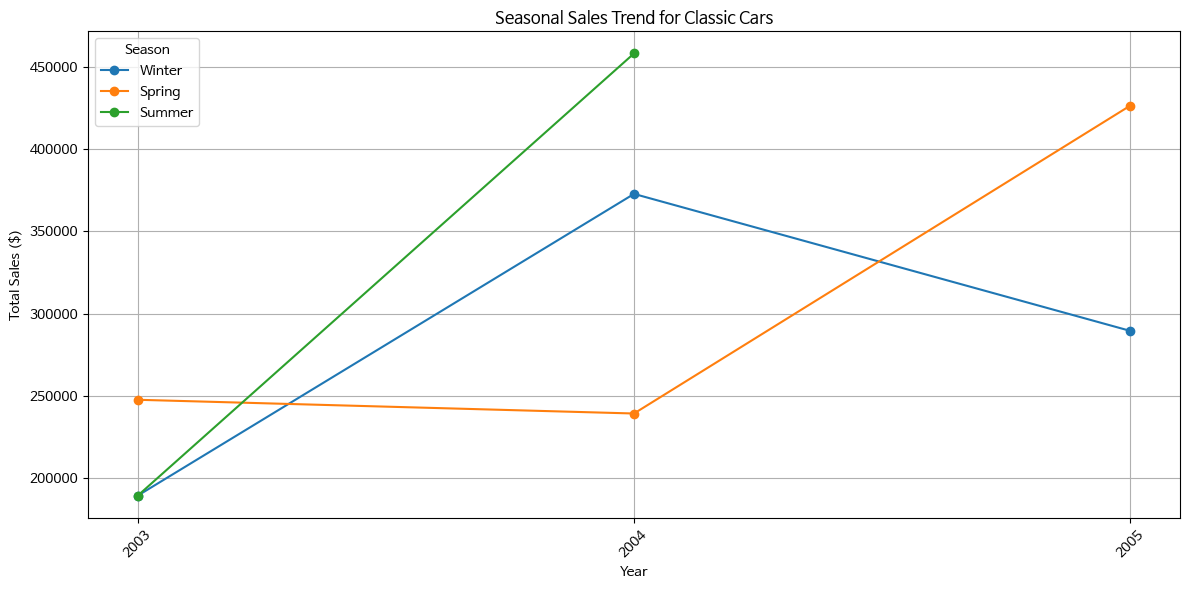

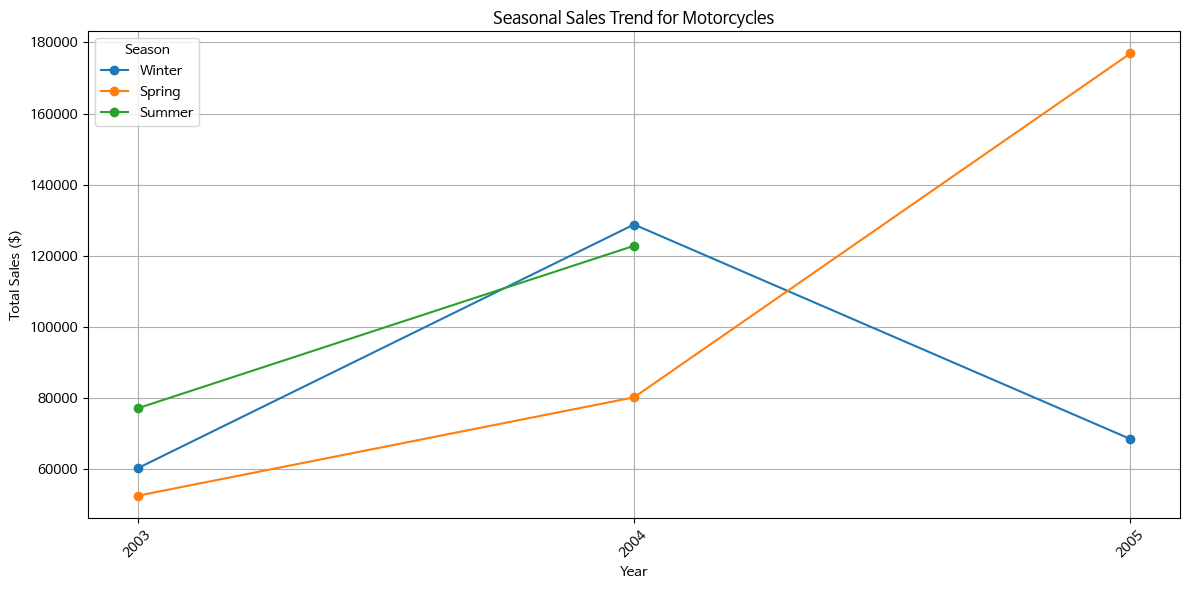

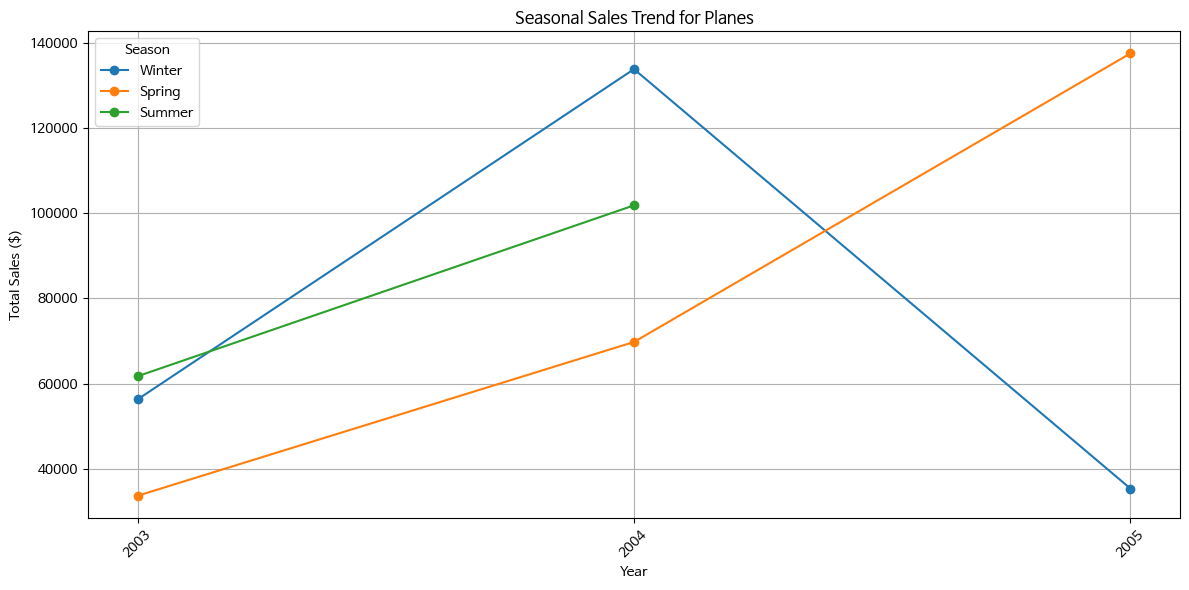

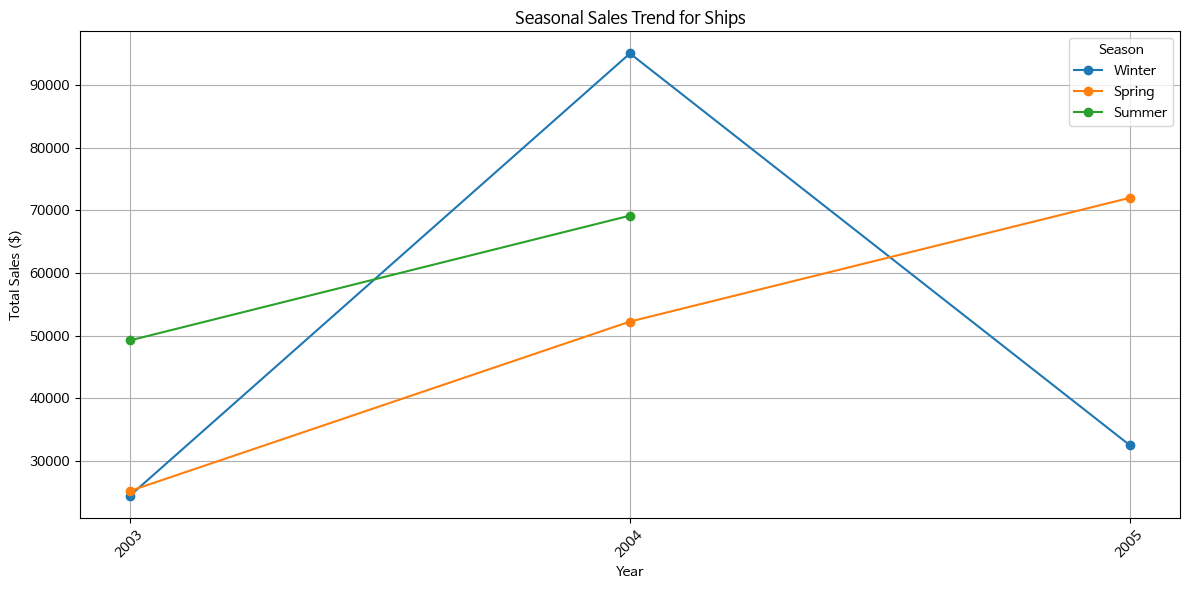

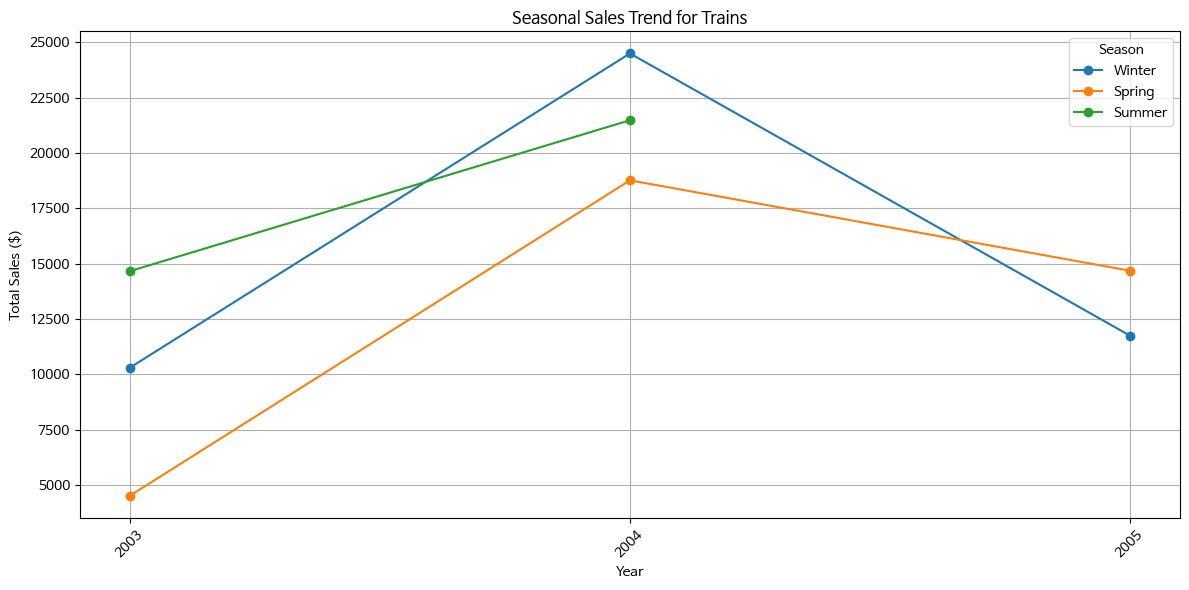

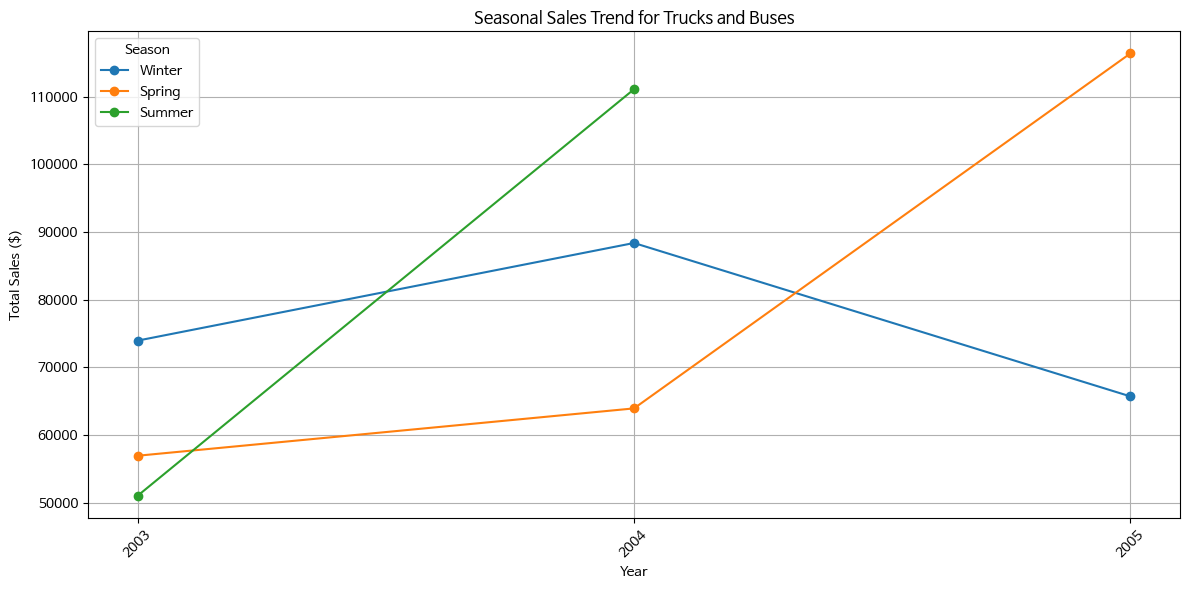

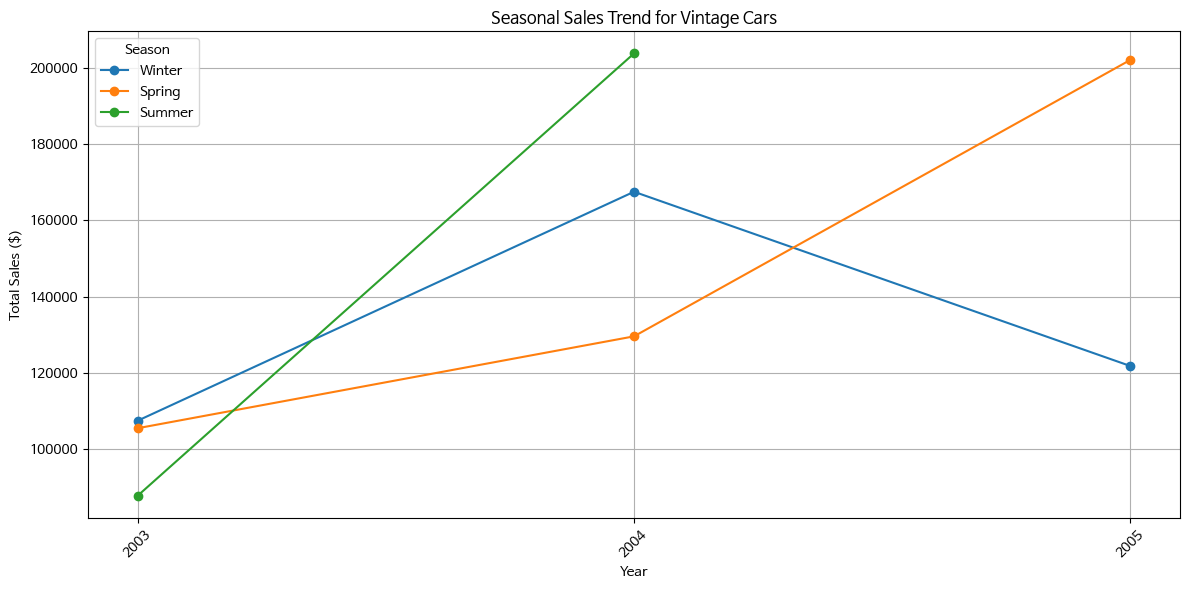

In [34]:
# 제품군과 시즌별로 데이터를 분리하여 시각화
product_lines = df['productLine'].unique()
seasons = ['Winter', 'Spring', 'Summer', 'Fall']

for product_line in product_lines:
    plt.figure(figsize=(12, 6))
    for season in seasons:
        subset = df[(df['productLine'] == product_line) & (df['season'] == season)]
        if not subset.empty:
            plt.plot(subset['orderYear'].astype(str), subset['total_sales'], marker='o', linestyle='-', label=season)

    plt.title(f'Seasonal Sales Trend for {product_line}')
    plt.xlabel('Year')
    plt.ylabel('Total Sales ($)')
    plt.legend(title='Season')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 회사 입장에서 취할수 있는 행동
- 시즌별 마케팅 전략 조정: 분석 결과를 통해 특정 시즌에 판매가 증가하는 제품군을 확인한 경우, 해당 시즌에 맞춰 마케팅 활동을 강화하여 판매를 더욱 촉진할 수 있음
- 재고 관리 최적화: 시즌별 판매 추세를 이해함으로써, 재고 수준을 조절하여 과잉 재고 또는 재고 부족 상황을 방지할 수 있음.
신제품 개발 및 기존 제품 개선: 일부 제품군이 특정 시즌에 성과가 저조한 경우, 제품 개선이나 신제품 개발을 통해 시장 수요를 더 잘 충족시킬 수 있도록 조치를 취할 수 있음.
- 시장 기회 식별: 분석을 통해 아직 충분히 활용되지 않은 시즌별 판매 기회를 식별할 수 있음
- 경쟁 우위 확보: 시즌별 판매 데이터를 분석함으로써, 경쟁사 대비 우리 회사의 제품군이 가지는 경쟁 우위를 파악하고 이를 기반으로 시장에서의 입지를 강화할 수 있음.
